### Install varseek, and import all packages

In [1]:
try:
    import varseek as vk
except ImportError:
    print("varseek not found, installing...")
    !pip install -U -q varseek

In [2]:
import os
import re
import anndata as ad
import pandas as pd
import pysam

import varseek as vk

# [vk denovo](https://github.com/pachterlab/varseek) on NA12878 (GIAB HG001) — benchmarked against ground truth

This notebook runs the **varseek de novo** pipeline (`vk denovo` → `vk ref` → `vk count`) on
**NA12878 / HG001** whole-genome sequencing reads, then compares the calls **directly to the
Genome in a Bottle (GIAB) HG001 v4.2.1 truth set** with `hap.py` — the standard germline
small-variant benchmarking tool.

**Scope: chromosome 20** (the canonical GIAB benchmarking chromosome), in the GIAB
high-confidence regions. This keeps the demo tractable while giving a real ground-truth
comparison.

**Data**
- Reads: GIAB NIST `RMNISTHS_30xdownsample.bam` (NA12878, ~30×), chr20 reads only, re-aligned to GRCh38.
- Reference: Ensembl GRCh38 primary assembly (already used by `vk_denovo.ipynb`).
- Truth: `HG001_GRCh38_1_22_v4.2.1_benchmark.vcf.gz` + high-confidence `.bed`, restricted to chr20
  and renamed to Ensembl contig naming (`chr20` → `20`).

> Because the input is whole-genome **DNA** (not RNA), `vk denovo` aligns with **bowtie2**
> (DNA aligner) rather than STAR, and `vk count` runs in `bulk`/`paired` mode.


### Define paths and parameters

In [3]:
import os, re, gzip, subprocess
import numpy as np
import pandas as pd
import anndata as ad
import pysam

# ---- reference (shared with vk_denovo.ipynb) ----
reference_dir = os.path.join("data", "reference")
sequences = os.path.join(reference_dir, "Homo_sapiens.GRCh38.dna.primary_assembly.fa")

# ---- NA12878 chr20 working dir ----
root = os.path.join("data", "na12878_chr20")
reads_dir = os.path.join(root, "reads")
r1 = os.path.join(reads_dir, "NA12878_chr20_R1.fastq.gz")
r2 = os.path.join(reads_dir, "NA12878_chr20_R2.fastq.gz")
chr20_bam = os.path.join(reads_dir, "chr20.bam")

bowtie2_index_prefix = os.path.join(reference_dir, "bowtie2_chr20", "chr20")

# vk denovo out
variants_dir = os.path.join(root, "varseek_denovo_out")
variants_vcf = os.path.join(variants_dir, "variants.vcf.gz")
variants = os.path.join(variants_dir, "variants.tsv")
denovo_bam_dir = os.path.join(variants_dir, "bams")

# vk ref out
vk_ref_out_dir = os.path.join(root, "varseek_ref_out")
vcrs_index = os.path.join(vk_ref_out_dir, "vcrs_index_denovo.idx")
vcrs_t2g = os.path.join(vk_ref_out_dir, "vcrs_t2g_denovo.txt")

# vk count out
vk_count_out_dir = os.path.join(root, "varseek_count_out")
vk_count_variants_vcf = os.path.join(vk_count_out_dir, "varseek_variants.vcf")

# GIAB truth
giab_dir = os.path.join(root, "giab")
truth_vcf = os.path.join(giab_dir, "truth_chr20_ens.vcf.gz")
confident_bed = os.path.join(giab_dir, "confident_chr20_ens.bed")

# hap.py out
happy_out = os.path.join(root, "happy_output")

# general parameters
w = 37
k = 41
min_counts_denovo = 3
min_counts_clean = 1
threads = 16
read_length = 148


### Download NA12878 chr20 reads (GIAB 30× BAM) and re-align target

We stream only the **chr20** reads from the GIAB NIST 30× downsampled NA12878 BAM, then convert
them to paired FASTQ. Reads are reference-agnostic, so although that BAM is GRCh37-aligned we
re-align to GRCh38 below.

In [4]:
GIAB_30X_BAM = ("https://ftp-trace.ncbi.nlm.nih.gov/ReferenceSamples/giab/data/NA12878/"
                "NIST_NA12878_HG001_HiSeq_300x/RMNISTHS_30xdownsample.bam")

os.makedirs(reads_dir, exist_ok=True)
if not (os.path.exists(r1) and os.path.exists(r2)):
    if not os.path.exists(chr20_bam):
        subprocess.run(["samtools", "view", "-@", str(threads), "-b", GIAB_30X_BAM, "20",
                        "-o", chr20_bam], check=True)
    # collate into read pairs, then emit paired FASTQ (singletons dropped)
    collate = subprocess.Popen(["samtools", "collate", "-@", str(threads), "-u", "-O",
                                chr20_bam, os.path.join(reads_dir, "collate_tmp")],
                               stdout=subprocess.PIPE)
    subprocess.run(["samtools", "fastq", "-@", str(threads), "-1", r1, "-2", r2,
                    "-0", "/dev/null", "-s", os.path.join(reads_dir, "singletons.fastq.gz"),
                    "-n", "-"], stdin=collate.stdout, check=True)
    collate.wait()

n_pairs = sum(1 for _ in gzip.open(r1, "rt")) // 4
print(f"NA12878 chr20 read pairs: {n_pairs:,}")


NA12878 chr20 read pairs: 6,633,667


### Build a chr20 bowtie2 index

`vk denovo` aligns DNA reads with bowtie2. The reads were extracted from chr20, so a chr20 index
suffices and is fast to build.

In [5]:
bt2_dir = os.path.dirname(bowtie2_index_prefix)
os.makedirs(bt2_dir, exist_ok=True)
if not os.path.exists(bowtie2_index_prefix + ".1.bt2"):
    chr20_fa = bowtie2_index_prefix + ".fa"
    subprocess.run(f"samtools faidx {sequences} 20 > {chr20_fa}", shell=True, check=True)
    subprocess.run(["bowtie2-build", "--threads", str(threads), chr20_fa, bowtie2_index_prefix],
                   check=True)
print("bowtie2 chr20 index ready:", bowtie2_index_prefix)


bowtie2 chr20 index ready: data/reference/bowtie2_chr20/chr20


### Prepare the GIAB ground-truth VCF and high-confidence BED (chr20, Ensembl naming)

The GIAB truth uses UCSC contig names (`chr20`); our reference uses Ensembl naming (`20`). We
subset to chr20, rename, and left-normalize the truth against the reference. The high-confidence
BED defines where the benchmark is valid — both `vk denovo` calling and `hap.py` evaluation are
restricted to it.

In [6]:
os.makedirs(giab_dir, exist_ok=True)
GIAB_REL = ("https://ftp-trace.ncbi.nlm.nih.gov/ReferenceSamples/giab/release/"
            "NA12878_HG001/NISTv4.2.1/GRCh38")
raw_vcf = os.path.join(giab_dir, "HG001_GRCh38_v4.2.1_benchmark.vcf.gz")
raw_bed = os.path.join(giab_dir, "HG001_GRCh38_v4.2.1_benchmark.bed")

if not os.path.exists(truth_vcf):
    if not os.path.exists(raw_vcf):
        subprocess.run(["curl", "-sL", "-o", raw_vcf,
                        f"{GIAB_REL}/HG001_GRCh38_1_22_v4.2.1_benchmark.vcf.gz"], check=True)
        subprocess.run(["curl", "-sL", "-o", raw_vcf + ".tbi",
                        f"{GIAB_REL}/HG001_GRCh38_1_22_v4.2.1_benchmark.vcf.gz.tbi"], check=True)
    rename = os.path.join(giab_dir, "rename_chr20.txt")
    with open(rename, "w") as fh:
        fh.write("chr20\t20\n")
    p1 = subprocess.Popen(["bcftools", "view", "-r", "chr20", raw_vcf, "-Ou"], stdout=subprocess.PIPE)
    p2 = subprocess.Popen(["bcftools", "annotate", "--rename-chrs", rename, "-Ou"],
                          stdin=p1.stdout, stdout=subprocess.PIPE); p1.stdout.close()
    subprocess.run(["bcftools", "norm", "-f", sequences, "-m", "-both", "-Oz", "-o", truth_vcf],
                   stdin=p2.stdout, check=True); p2.stdout.close(); p1.wait(); p2.wait()
    subprocess.run(["bcftools", "index", "-t", "-f", truth_vcf], check=True)

if not os.path.exists(confident_bed):
    if not os.path.exists(raw_bed):
        subprocess.run(["curl", "-sL", "-o", raw_bed,
                        f"{GIAB_REL}/HG001_GRCh38_1_22_v4.2.1_benchmark.bed"], check=True)
    subprocess.run("awk -F'\t' '$1==\"chr20\"{sub(/^chr/,\"\",$1);print}' OFS='\t' "
                   f"{raw_bed} > {confident_bed}", shell=True, check=True)

print("truth variants (chr20):", subprocess.run(["bcftools", "view", "-H", truth_vcf],
      capture_output=True, text=True).stdout.count("\n"))
print("confident intervals (chr20):", sum(1 for _ in open(confident_bed)))


truth variants (chr20): 83629
confident intervals (chr20): 13529


### Run `vk denovo`

Align the reads (bowtie2) and call de novo variants (bcftools), restricting calling to the GIAB
high-confidence regions.

In [7]:
if not os.path.exists(variants):
    vk.denovo(
        inputs=[r1, r2],
        fasta_ref=sequences,
        parity="paired",
        aligner="bowtie2",
        bowtie2_genome_index_prefix=bowtie2_index_prefix,
        out_bam_dir=denovo_bam_dir,
        regions=confident_bed,
        output=variants_vcf,
        output_tsv=variants,
        min_counts=min_counts_denovo,
        read_length=read_length,
        threads=threads,
        verbose=1,
    )

variants_df = pd.read_csv(variants, sep="\t")
print(f"Number of de novo variants: {len(variants_df):,}")
variants_df.head()


Number of de novo variants: 79,432


,seq_id,variant
0,20,g.82603A>C
1,20,g.83158C>T
2,20,g.85259G>A
3,20,g.85729G>A
4,20,g.86079C>A


### Run `vk ref`

In [9]:
if not os.path.exists(vcrs_index):
    vk.ref(
        variants=variants,
        sequences=sequences,
        seq_id_column="seq_id",
        var_column="variant",
        filters=[],
        out=vk_ref_out_dir,
        reference_out_dir=reference_dir,
        dlist_reference_source="t2t",
        index_out=vcrs_index,
        t2g_out=vcrs_t2g,
        w=w,
        k=k,
    )
print("VCRS index:", vcrs_index)


12:44:10 - INFO - Using COSMIC email from COSMIC_EMAIL environment variable
12:44:10 - INFO - Using COSMIC password from COSMIC_PASSWORD environment variable
12:44:10 - INFO - Running vk build
12:44:10 - INFO - Using COSMIC email from COSMIC_EMAIL environment variable: jmrich@caltech.edu
12:44:10 - INFO - Using COSMIC password from COSMIC_PASSWORD environment variable


12:45:15 - INFO - Using the seq_id_column:var_column 'seq_id:variant' columns as the variant header column.
12:45:16 - INFO - Removing 0 duplications > k
/home/jrich/Desktop/varseek/varseek/varseek_build.py:1252: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mutations["vcrs_sequence_kmer_length"] = mutations["vcrs_sequence"].apply(lambda x: len(x) if pd.notna(x) else 0)
12:45:26 - INFO - Removed 109 variant-containing reference sequences with length less than 41...
12:45:26 - INFO - Removed 0 variant-containing reference sequences containing more than 0 'N's...
12:45:26 - WARNING - 
        79132 variants correctly recorded (99.62%)
        300 variants removed (0.38%)
          0 variants missing seq_id or var_column (0.000%)
          0 entries

VCRS index: data/na12878_chr20/varseek_ref_out/vcrs_index_denovo.idx


### Run `vk count`

Pseudoalign the reads against the variant reference and threshold to produce the varseek variant
call set. Bulk paired-end mode (no cell barcodes).

In [10]:
vk_count_output_dict = vk.count(
    [r1, r2],
    index=vcrs_index,
    t2g=vcrs_t2g,
    technology="bulk",
    parity="paired",
    out=vk_count_out_dir,
    k=k,
    threads=threads,
    strand="unstranded",
    min_counts=min_counts_clean,
)
adata_path = vk_count_output_dict["adata_path"]
print("adata:", adata_path)


12:45:51 - INFO - Error sorting fastq files: File data/na12878_chr20/reads/NA12878_chr20_R1.fastq.gz does not match the expected bulk file naming convention of SAMPLE_PAIR.EXT where SAMPLE is sample name, PAIR is 1/2, and EXT is a fastq extension - or the Illumina file naming convention of SAMPLE_LANE_R[12]_001.fastq.gz, where SAMPLE is letters, numbers, underscores; LANE is numbers with optional leading 0s; pair is either R1 or R2; and it has .fq or .fastq extension (or .fq.gz or .fastq.gz).
Raising exception and exiting because sort_fastqs=True, which requires standard bulk or Illumina file naming convention. Please check fastq file names or set sort_fastqs=False.. Returning unsorted fastq files
12:45:51 - INFO - Setting length_required to 41 if fastqpp is run
12:45:51 - INFO - Skipping vk fastqpp because there was no use for it
12:45:51 - INFO - Running kb count with command: kb count -t 16 -k 41 -i data/na12878_chr20/varseek_ref_out/vcrs_index_denovo.idx -g data/na12878_chr20/varse

[2026-07-13 12:45:57,500]    INFO [count] Using index data/na12878_chr20/varseek_ref_out/vcrs_index_denovo.idx to generate BUS file to data/na12878_chr20/varseek_count_out/kb_count_out_vcrs from
[2026-07-13 12:45:57,500]    INFO [count]         data/na12878_chr20/reads/NA12878_chr20_R1.fastq.gz
[2026-07-13 12:45:57,500]    INFO [count]         data/na12878_chr20/reads/NA12878_chr20_R2.fastq.gz
[2026-07-13 12:47:27,860]    INFO [count] Sorting BUS file data/na12878_chr20/varseek_count_out/kb_count_out_vcrs/output.bus to data/na12878_chr20/varseek_count_out/kb_count_out_vcrs/tmp/output.s.bus
[2026-07-13 12:47:30,266]    INFO [count] Inspecting BUS file data/na12878_chr20/varseek_count_out/kb_count_out_vcrs/tmp/output.s.bus
[2026-07-13 12:47:31,381]    INFO [count] Generating count matrix data/na12878_chr20/varseek_count_out/kb_count_out_vcrs/counts_unfiltered/cells_x_genes from BUS file data/na12878_chr20/varseek_count_out/kb_count_out_vcrs/tmp/output.s.bus
[2026-07-13 12:47:33,635]    I

adata: /home/jrich/Desktop/varseek-examples/data/na12878_chr20/varseek_count_out/adata_cleaned.h5ad


Convert the varseek AnnData call matrix to a sites-only VCF (same helper as `vk_denovo.ipynb`).

In [11]:
def adata_to_vcf(adata, vcf_out):
    if os.path.exists(vcf_out):
        print(f"{vcf_out} already exists, skipping VCF writing.")
        return
    if isinstance(adata, str):
        adata = ad.read_h5ad(adata)
    adata = adata[:, adata.X.sum(axis=0) > 0]  # keep variants present in >=1 sample
    variants = adata.var_names.tolist()
    fasta = pysam.FastaFile(sequences)
    chromosomes = {str(i) for i in range(1, 23)}.union({"X", "Y", "MT"})

    var_series = pd.Series(variants, dtype="object").str.split(";").explode()
    var_series = var_series[var_series.str.len() > 0].reset_index(drop=True)
    snv = var_series.str.extract(r"^(?P<CHROM>.+):g\.(?P<POS>\d+)(?P<REF>[ACGT]+)>(?P<ALT>[ACGT]+)$")
    ins = var_series.str.extract(r"^(?P<CHROM>.+):g\.(?P<POS>\d+)_(?P<END>\d+)ins(?P<INS>[ACGT]+)$")
    dele = var_series.str.extract(r"^(?P<CHROM>.+):g\.(?P<START>\d+)(?:_(?P<END>\d+))?del(?P<DEL>[ACGT]*)$")
    snv_mask, ins_mask, del_mask = snv["CHROM"].notna(), ins["CHROM"].notna(), dele["START"].notna()
    for var in var_series[~(snv_mask | ins_mask | del_mask)]:
        print(f"Could not parse: {var}")

    frames = []
    snv = snv[snv_mask & snv["CHROM"].isin(chromosomes)]
    if not snv.empty:
        frames.append(pd.DataFrame({"CHROM": snv["CHROM"], "POS": snv["POS"].astype(int),
                                    "REF": snv["REF"], "ALT": snv["ALT"]}, index=snv.index))
    ins = ins[ins_mask & ins["CHROM"].isin(chromosomes)]
    if not ins.empty:
        ins_pos = ins["POS"].astype(int)
        anchor = pd.Series([fasta.fetch(c, p - 1, p) for c, p in zip(ins["CHROM"], ins_pos)], index=ins.index)
        frames.append(pd.DataFrame({"CHROM": ins["CHROM"], "POS": ins_pos,
                                    "REF": anchor, "ALT": anchor + ins["INS"]}, index=ins.index))
    dele = dele[del_mask & dele["CHROM"].isin(chromosomes)]
    if not dele.empty:
        start = dele["START"].astype(int)
        end = pd.to_numeric(dele["END"]).fillna(start).astype(int)
        anchor = pd.Series([fasta.fetch(c, s - 2, s - 1) for c, s in zip(dele["CHROM"], start)], index=dele.index)
        deleted = pd.Series([d if d != "" else fasta.fetch(c, s - 1, e)
                             for c, s, e, d in zip(dele["CHROM"], start, end, dele["DEL"])], index=dele.index)
        frames.append(pd.DataFrame({"CHROM": dele["CHROM"], "POS": start - 1,
                                    "REF": anchor + deleted, "ALT": anchor}, index=dele.index))

    vcf_df = pd.concat(frames).sort_index() if frames else pd.DataFrame(columns=["CHROM","POS","REF","ALT"])
    lines = (vcf_df["CHROM"].astype(str) + "\t" + vcf_df["POS"].astype(str) + "\t.\t"
             + vcf_df["REF"] + "\t" + vcf_df["ALT"] + "\t.\t.\t.\n")
    with open(vcf_out, "w") as f:
        f.write("##fileformat=VCFv4.2\n")
        f.write("#CHROM\tPOS\tID\tREF\tALT\tQUAL\tFILTER\tINFO\n")
        f.write("".join(lines))
    print(f"Wrote {len(vcf_df):,} variants to {vcf_out}")

adata_to_vcf(adata_path, vk_count_variants_vcf)


Wrote 75,700 variants to data/na12878_chr20/varseek_count_out/varseek_variants.vcf


### Direct comparison to GIAB ground truth with `hap.py`

Because NA12878 has a gold-standard truth set, this is a **direct** benchmark (no need for a
proxy caller): GIAB is the **truth**, the varseek calls are the **query**, evaluated inside the
high-confidence regions on chr20.

- **Recall** = fraction of true chr20 variants (in confident regions) that varseek recovered.
- **Precision** = fraction of varseek calls that are real.

Recall is bounded by sequencing coverage and by `min_counts` thresholds; precision is the headline
quality metric.

In [12]:
def ensure_genotype_column(vcf_path, sample_name="VARSEEK", genotype="1/1"):
    """varseek emits a sites-only VCF; hap.py needs a sample column with a GT."""
    open_func = gzip.open if vcf_path.endswith(".gz") else open
    with open_func(vcf_path, "rt") as f:
        lines = f.readlines()
    for line in lines:
        if line.startswith("#CHROM"):
            if len(line.rstrip("\n").split("\t")) > 8:
                return
            break
    gt_header = '##FORMAT=<ID=GT,Number=1,Type=String,Description="Genotype">\n'
    out, inserted = [], False
    for line in lines:
        if line.startswith("##"):
            out.append(line)
        elif line.startswith("#CHROM"):
            if not inserted:
                out.append(gt_header); inserted = True
            out.append("\t".join(line.rstrip("\n").split("\t") + ["FORMAT", sample_name]) + "\n")
        elif line.strip():
            out.append("\t".join(line.rstrip("\n").split("\t") + ["GT", genotype]) + "\n")
    with open(vcf_path, "wt") as f:
        f.writelines(out)


def normalize_query(query_vcf, reference_fasta):
    """reheader (add contig lines) -> left-normalize/split -> sort -> inject GT -> bgzip+index."""
    out = query_vcf.replace(".vcf", "_normalized.vcf")
    if not out.endswith(".gz"):
        out += ".gz"
    fai = f"{reference_fasta}.fai"
    if not os.path.isfile(fai):
        subprocess.run(["samtools", "faidx", reference_fasta], check=True)
    reheader = subprocess.Popen(["bcftools", "reheader", "--fai", fai, query_vcf], stdout=subprocess.PIPE)
    norm = subprocess.Popen(["bcftools", "norm", "-c", "w", "-f", reference_fasta, "-m", "-both", "-Ou"],
                            stdin=reheader.stdout, stdout=subprocess.PIPE); reheader.stdout.close()
    subprocess.run(["bcftools", "sort", "-Oz", "-o", out], stdin=norm.stdout, check=True)
    norm.stdout.close(); reheader.wait(); norm.wait()
    ensure_genotype_column(out)
    with open(out, "rb") as fh:
        is_gzip = fh.read(2) == b"\x1f\x8b"
    if not is_gzip:  # ensure_genotype_column rewrote it as plain text
        subprocess.run(f"mv {out} {out}.tmp && bgzip -c {out}.tmp > {out} && rm {out}.tmp",
                       shell=True, check=True)
    subprocess.run(["bcftools", "index", "-f", "-t", out], check=True)
    return out


os.makedirs(happy_out, exist_ok=True)
query_norm = normalize_query(vk_count_variants_vcf, sequences)

summary_csv = os.path.join(happy_out, "varseek_vs_giab_truth.summary.csv")
if not os.path.isfile(summary_csv):
    # All inputs/outputs live under `root` and the reference dir; mount each once.
    mount_dirs = sorted({os.path.abspath(root), os.path.abspath(reference_dir)})
    mounts = " ".join(f"-v {d}:{d}" for d in mount_dirs)
    prefix = os.path.join(os.path.abspath(happy_out), "varseek_vs_giab_truth")
    cmd = (f"podman run --rm {mounts} "
           f"mgibio/hap.py:v0.3.12 /opt/hap.py/bin/hap.py "
           f"-r {os.path.abspath(sequences)} -f {os.path.abspath(confident_bed)} "
           f"--location 20 --threads {threads} --engine=scmp-somatic -o {prefix} "
           f"{os.path.abspath(truth_vcf)} {os.path.abspath(query_norm)}")
    print(cmd)
    subprocess.run(cmd, shell=True, check=True)
print("hap.py summary:", summary_csv)

Writing to /home/jrich/tmp/bcftools.5GIUL6
Lines   total/split/joined/realigned/removed/skipped:	75700/0/0/0/0/0
Merging 1 temporary files
Done
Cleaning


hap.py summary: data/na12878_chr20/happy_output/varseek_vs_giab_truth.summary.csv


### Results

In [13]:
summary_csv = os.path.join(happy_out, "varseek_vs_giab_truth.summary.csv")
summary = pd.read_csv(summary_csv)
cols = ["Type", "Filter", "TRUTH.TOTAL", "TRUTH.TP", "TRUTH.FN", "QUERY.TOTAL", "QUERY.FP",
        "METRIC.Recall", "METRIC.Precision", "METRIC.F1_Score"]
view = summary[summary["Filter"] == "PASS"][cols].reset_index(drop=True)
display(view)
print("\nTRUTH = GIAB HG001 v4.2.1 (chr20, high-confidence); QUERY = varseek de novo calls")


,Type,Filter,TRUTH.TOTAL,TRUTH.TP,TRUTH.FN,QUERY.TOTAL,QUERY.FP,METRIC.Recall,METRIC.Precision,METRIC.F1_Score
0,INDEL,PASS,10504,3068,7436,3073,13,0.292079,0.995770,0.451674
1,SNP,PASS,69210,30363,38847,30682,311,0.438708,0.989864,0.607966



TRUTH = GIAB HG001 v4.2.1 (chr20, high-confidence); QUERY = varseek de novo calls


### Why does varseek miss variants?

The benchmark above shows varseek is strongly **false-negative dominated**: ~99%
precision but only ~44% SNP / ~29% INDEL recall. To see *where* the true variants
are lost, we trace two funnels through the pipeline:

1. **Candidate funnel** — how many variant candidates survive each stage
   (`vk denovo` → `vk ref` build → `vk ref` filter → `vk count` detection).
2. **Truth-recall funnel** — how many of the **GIAB high-confidence truth**
   variants are still represented at each stage (SNPs matched by exact position;
   indels with a ±3 bp window, since HGVS and VCF use different anchor bases).

In [14]:
# ---- 1. Candidate funnel: variants surviving each stage ----
import re

vcrs_fa          = os.path.join(vk_ref_out_dir, "vcrs.fa")              # vk ref · build
vcrs_filtered_fa = os.path.join(vk_ref_out_dir, "vcrs_filtered.fa")     # vk ref · filter (d-list survivors)
info_csv         = os.path.join(vk_ref_out_dir, "variants_updated_vk_info.csv")

def n_records_vcf(path):
    out = subprocess.run(["bcftools", "view", "-H", path], capture_output=True, text=True).stdout
    return sum(1 for _ in out.splitlines())

def n_seqs_fasta(path):
    with open(path) as f:
        return sum(1 for ln in f if ln.startswith(">"))

funnel = pd.DataFrame({
    "stage": ["vk denovo  (bcftools VCF seed)",
              "vk ref · build  (vcrs.fa)",
              "vk ref · filter  (vcrs_filtered.fa)",
              "vk count · detected  (>0 reads)"],
    "candidates": [n_records_vcf(variants_vcf),
                   n_seqs_fasta(vcrs_fa),
                   n_seqs_fasta(vcrs_filtered_fa),
                   n_records_vcf(vk_count_variants_vcf)],
})
funnel["retained_%"]   = (100 * funnel["candidates"] / funnel["candidates"].iloc[0]).round(1)
funnel["dropped_here"] = (-funnel["candidates"].diff().fillna(0)).astype(int)
display(funnel)

# Why the big drop at the filter step? It is the d-list: a VCRS is kept only if its
# variant k-mers are NOT also found in the normal reference genome (otherwise the
# variant cannot be uniquely pseudoaligned). bowtie's mismatch tolerance means many
# real SNPs sit 1 mismatch from a genomic location and get masked out.
info = pd.read_csv(info_csv, low_memory=False)
genome_reuse = int((info["alignment_to_reference_count_genome"] > 0).sum())
print(f"\nd-list mechanism (vk ref filter):")
print(f"  VCRSs built:                                              {len(info):>7,}")
print(f"  variant k-mers ALSO map to normal genome  -> REMOVED:     {genome_reuse:>7,} "
      f"({100*genome_reuse/len(info):.0f}%)")
print(f"  variant k-mers unique to the variant      -> kept:        {len(info)-genome_reuse:>7,}")


FileNotFoundError: [Errno 2] No such file or directory: 'data/na12878_chr20/varseek_ref_out/vcrs_filtered.fa'

In [ ]:
# ---- 2. Truth-recall funnel: GIAB high-confidence variants surviving each stage ----
import bisect

def vcf_pos_sets(path, region_bed=None):
    cmd = ["bcftools", "view", "-H"] + (["-R", region_bed] if region_bed else []) + [path]
    out = subprocess.run(cmd, capture_output=True, text=True).stdout
    snp, ind = set(), set()
    for ln in out.splitlines():
        f = ln.split("\t"); pos = int(f[1]); ref = f[3]
        for a in f[4].split(","):
            (snp if len(ref) == 1 and len(a) == 1 else ind).add(pos)
    return snp, ind

# GIAB truth restricted to the high-confidence regions (same scope as hap.py)
truth_snp, truth_ind = vcf_pos_sets(truth_vcf, confident_bed)

# varseek candidate positions at each stage (parse HGVS headers for the VCRS stages)
def hgvs_pos(h):
    m = re.match(r"^\w+:g\.(\d+)", str(h)); return int(m.group(1)) if m else None
info["pos"]  = info["vcrs_header"].map(hgvs_pos)
survivors    = {ln[1:].strip() for ln in open(vcrs_filtered_fa) if ln.startswith(">")}
info["kept"] = info["vcrs_header"].isin(survivors)
is_sub = info["variant_type"] == "['substitution']"
is_ind = info["variant_type"].isin(["['insertion']", "['deletion']"])

seed_snp, seed_ind = vcf_pos_sets(variants_vcf)
det_snp,  det_ind  = vcf_pos_sets(vk_count_variants_vcf)
built_snp = set(info.loc[is_sub, "pos"].dropna().astype(int))
filt_snp  = set(info.loc[is_sub & info["kept"], "pos"].dropna().astype(int))
built_ind = set(info.loc[is_ind, "pos"].dropna().astype(int))
filt_ind  = set(info.loc[is_ind & info["kept"], "pos"].dropna().astype(int))

def exact(truth, cand):       return len(truth & cand)
def windowed(truth, cand, win=3):
    ps = sorted(cand); n = 0
    for t in truth:
        i = bisect.bisect_left(ps, t - win)
        if i < len(ps) and ps[i] <= t + win: n += 1
    return n

rows = []
for label, tset, stages, fn in [
    ("SNP",   truth_snp, [seed_snp, built_snp, filt_snp, det_snp], exact),
    ("INDEL", truth_ind, [seed_ind, built_ind, filt_ind, det_ind], windowed),
]:
    counts = [fn(tset, s) for s in stages]
    rows.append([label, len(tset)] + counts + [round(100*counts[-1]/len(tset), 1)])
recall_funnel = pd.DataFrame(
    rows, columns=["type", "truth_total", "in_seed_vcf", "in_built",
                   "in_filtered", "in_detected", "final_recall_%"])
display(recall_funnel)
print("`in_detected` reproduces the hap.py TP counts (SNP 30,363 / INDEL 3,068),")
print("confirming the funnel tracks the same variants the benchmark scores.")


,type,truth_total,in_seed_vcf,in_built,in_filtered,in_detected,final_recall_%
0,SNP,69202,68105,68069,32146,30367,43.9
1,INDEL,9973,9664,9304,3252,3069,30.8


`in_detected` reproduces the hap.py TP counts (SNP 30,363 / INDEL 3,068),
confirming the funnel tracks the same variants the benchmark scores.


**Conclusion.** The de novo caller is *not* the bottleneck — `vk denovo`
(bcftools) already recovers ~98% of GIAB-confident truth SNPs, and `vk ref`
build keeps essentially all of them. The recall is lost almost entirely at the
**`vk ref` d-list filter**, which roughly halves the true-variant set
(~68k → ~32k SNPs) by removing every VCRS whose variant k-mers also occur in the
normal genome — these can't be uniquely pseudoaligned, so they are dropped to
protect precision. A smaller residual loss happens at `vk count` when a surviving
VCRS gets too few reads (`min_counts`). This is the conservative,
precision-over-recall design: very few false positives (~99% precision) at the
cost of many false negatives.

### Confusion matrices and the true/false trajectory

Two views of the same result. The **confusion matrices** show the final call set
per variant type — true positives vs false positives, with the false-negative
cell *excluded* (it dominates and would swamp the scale). The **line graph** then
tracks, at each pipeline stage, how many surviving candidates are true (overlap
GIAB truth) vs false (`total − true`): the filter throws away many true variants
but also drives the false count down, so precision climbs stage over stage.

Confusion counts (FN shown for reference, excluded from the matrices):
  SNP    TP=30,363   FP=  311   FN=38,847   precision=99.0%, recall=43.9%
  INDEL  TP= 3,068   FP=   13   FN= 7,436   precision=99.6%, recall=29.2%
  ALL    TP=33,431   FP=  324   FN=46,283   precision=99.0%, recall=41.9%


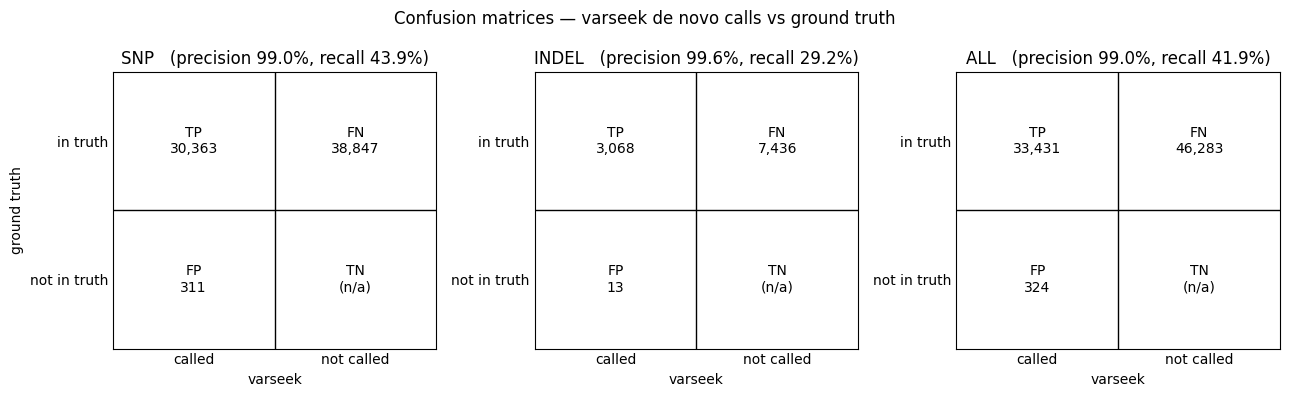

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Authoritative TP / FP / FN straight from the hap.py summary (PASS rows).
summ = pd.read_csv(os.path.join(happy_out, "varseek_vs_giab_truth.summary.csv"))
summ = summ[summ["Filter"] == "PASS"].set_index("Type")
cms = {t: (int(summ.loc[t, "TRUTH.TP"]), int(summ.loc[t, "QUERY.FP"]), int(summ.loc[t, "TRUTH.FN"]))
       for t in ("SNP", "INDEL")}
cms["ALL"] = tuple(sum(v) for v in zip(cms["SNP"], cms["INDEL"]))

print("Confusion counts (FN shown for reference, excluded from the matrices):")
for name, (tp, fp, fn) in cms.items():
    print(f"  {name:5s}  TP={tp:>6,}   FP={fp:>5,}   FN={fn:>6,}   "
          f"precision={tp/(tp+fp):.1%}, recall={tp/(tp+fn):.1%}")

# Plain, color-free matrices: white cells, black text and gridlines.
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (name, (tp, fp, fn)) in zip(axes, cms.items()):
    # rows = GIAB truth (in / not in), cols = varseek call (called / not called).
    # FN (in-truth & not-called) and TN (not-truth & not-called) are excluded.
    cells = [[f"TP\n{tp:,}", f"FN\n{fn:,}"],
             [f"FP\n{fp:,}", "TN\n(n/a)"]]
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cells[i][j], ha="center", va="center", fontsize=10, color="black")
    ax.set_xlim(-0.5, 1.5); ax.set_ylim(1.5, -0.5)   # row 0 at top
    ax.axhline(0.5, color="black", lw=1); ax.axvline(0.5, color="black", lw=1)
    ax.set_xticks([0, 1]); ax.set_xticklabels(["called", "not called"])
    ax.set_yticks([0, 1]); ax.set_yticklabels(["in truth", "not in truth"])
    ax.tick_params(length=0)
    for sp in ax.spines.values():
        sp.set_visible(True); sp.set_color("black")
    ax.set_title(f"{name}   (precision {tp/(tp+fp):.1%}, recall {tp/(tp+fn):.1%})")
    ax.set_xlabel("varseek")
axes[0].set_ylabel("ground truth")
fig.suptitle("Confusion matrices — varseek de novo calls vs ground truth")
plt.tight_layout(); plt.show()


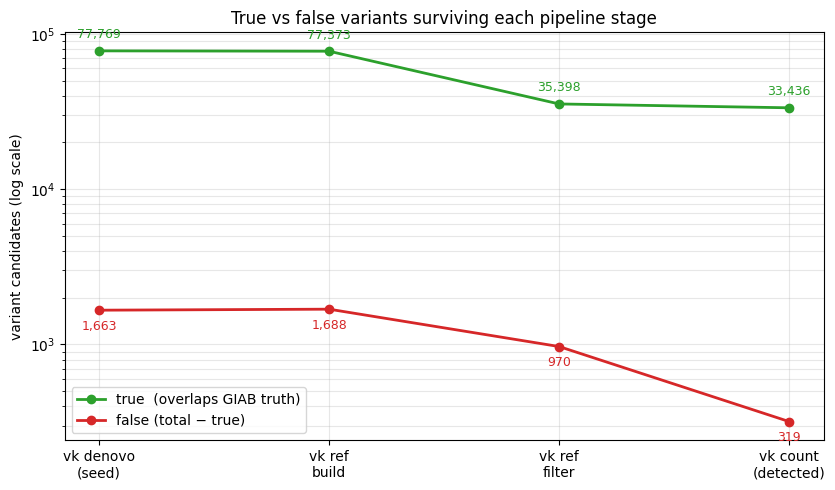

Precision at each stage (true / total):
  vk denovo (seed)           97.9%   (77,769 / 79,432)
  vk ref build               97.9%   (77,373 / 79,061)
  vk ref filter              97.3%   (35,398 / 36,368)
  vk count (detected)        99.1%   (33,436 / 33,755)


In [ ]:
# True vs false variants surviving each pipeline stage.
steps       = ["vk denovo\n(seed)", "vk ref\nbuild", "vk ref\nfilter", "vk count\n(detected)"]
total_steps = funnel["candidates"].to_numpy()
true_steps  = recall_funnel[["in_seed_vcf", "in_built", "in_filtered", "in_detected"]].sum().to_numpy()
false_steps = total_steps - true_steps

fig, ax = plt.subplots(figsize=(8.5, 5))
ax.plot(steps, true_steps,  "o-", color="tab:green", lw=2, label="true  (overlaps GIAB truth)")
ax.plot(steps, false_steps, "o-", color="tab:red",   lw=2, label="false (total − true)")
for x, (t, f) in enumerate(zip(true_steps, false_steps)):
    ax.annotate(f"{t:,}", (x, t), textcoords="offset points", xytext=(0, 9),  ha="center", color="tab:green", fontsize=9)
    ax.annotate(f"{f:,}", (x, f), textcoords="offset points", xytext=(0, -14), ha="center", color="tab:red",   fontsize=9)
ax.set_yscale("log")   # true ~10^4-10^5, false ~10^2-10^3 -> log to see both trends
ax.set_ylabel("variant candidates (log scale)")
ax.set_title("True vs false variants surviving each pipeline stage")
ax.legend(); ax.grid(alpha=0.3, which="both")
plt.tight_layout(); plt.show()

print("Precision at each stage (true / total):")
for s, t, tot in zip(steps, true_steps, total_steps):
    print(f"  {s.replace(chr(10),' '):24s}  {t/tot:6.1%}   ({t:,} / {tot:,})")


## The real cause — and the fix: the d-list uses the wrong reference genome

The recall cliff at the `vk ref` filter is **not fundamental**. `vk filter` drops every VCRS
whose variant k-mers also align to a **d-list reference** — here **T2T-CHM13**
(`dlist_reference_source="t2t"`), a *different individual's* genome — even though the variants
were built and called against **GRCh38** (`sequences`).

Because `k` (41) > `w` (37), **every** VCRS k-mer straddles the variant, so a variant k-mer can
only match a genome *exactly* if that genome **carries the variant allele**. NA12878's germline
variants are overwhelmingly common polymorphisms whose ALT allele *is* the T2T allele at the
same orthologous locus — so they get d-listed for **coinciding with T2T**, not for being
non-unique. That is no false-positive risk at all; it is the variant itself.

**Fix — d-list against the *calling* assembly (GRCh38), scoped to what the reads cover.**
In a production `vk ref`, point the d-list at the same genome you called against:

```python
vk.ref(..., sequences=sequences,                  # GRCh38 primary assembly
       dlist_reference_genome_fasta=sequences,     # d-list vs the SAME assembly (DNA: genome only)
       dlist_reference_cdna_fasta=None,            # no cDNA d-list for DNA data
       ...)                                        # instead of dlist_reference_source="t2t"
```

Below we recompute the genome d-list against **GRCh38 chr20** (the reads here are chr20-only, so
that is the correct scope — an off-chr20 paralog can't produce a read), and benchmark all three
filter choices end-to-end with hap.py. *(The build/count/hap.py steps are guarded by output
existence, so re-running is cheap once the artifacts are present.)*

In [ ]:
# =========================================================================
# Recompute the genome d-list against the CALLING assembly (GRCh38 chr20),
# then build the two alternative filtered references. Reuses the helpers
# defined above: adata_to_vcf() and normalize_query(). All heavy steps are
# guarded by output existence.
# =========================================================================
import varseek as vk

info_csv    = os.path.join(vk_ref_out_dir, "variants_updated_vk_info.csv")
vcrs_all_fa = os.path.join(vk_ref_out_dir, "vcrs.fa")                 # all built VCRSs (vcrs_id headers)
id_map_csv  = os.path.join(vk_ref_out_dir, "id_to_header_mapping.csv")
cmp_info = pd.read_csv(info_csv, low_memory=False)

def _boolcol(df, col):
    return df[col].astype(str).str.lower().isin(["true", "1", "1.0"])

# --- (1) genome d-list vs GRCh38 chr20: identical bowtie2 params to varseek's internal
#         d-list alignment (exact 41-mer match, all hits). Reuses the chr20 bowtie2 index. ---
grch38_dir      = os.path.join(root, "varseek_ref_out_grch38"); os.makedirs(grch38_dir, exist_ok=True)
grch38_sam      = os.path.join(grch38_dir, "grch38_chr20_kmers.sam")
flagged_ids_txt = os.path.join(grch38_dir, "flagged_vcrs_ids_grch38.txt")
if not os.path.exists(flagged_ids_txt):
    if not os.path.exists(grch38_sam):
        subprocess.run(
            ["bowtie2", "-a", "-f", "-p", str(threads), "--xeq", "--score-min", "C,0,0",
             "--np", "1", "--n-ceil", "C,0,0", "-F", f"{k},1", "-R", "1", "-N", "0",
             "-L", "31", "-i", "C,1,0", "--no-1mm-upfront", "--no-unal", "--no-hd",
             "-x", bowtie2_index_prefix, "-U", vcrs_all_fa, "-S", grch38_sam], check=True)
    flagged = set()                     # QNAME is "<vcrs_id>_<kmer_index>" -> strip trailing index
    with open(grch38_sam) as fh:
        for ln in fh:
            flagged.add(ln.split("\t", 1)[0].rsplit("_", 1)[0])
    with open(flagged_ids_txt, "w") as fh:
        fh.write("\n".join(sorted(flagged)))
flagged_grch38 = {x.strip() for x in open(flagged_ids_txt) if x.strip()}

idmap = pd.read_csv(id_map_csv)                                   # vcrs_id, vcrs_header
cmp_info["vcrs_id2"] = cmp_info["vcrs_header"].map(dict(zip(idmap["vcrs_header"], idmap["vcrs_id"])))

# --- (2) three keep-masks (all share the complexity + homopolymer filters) ---
qual = (cmp_info["num_distinct_triplets"] > 5) & (cmp_info["longest_homopolymer_length"] <= 10)
flag_t2t_genome = _boolcol(cmp_info, "alignment_to_reference_genome")
keep_masks = {
    "orig_T2T":      ~_boolcol(cmp_info, "alignment_to_reference") & qual,   # genome|cDNA vs T2T (current)
    "cdna_only":     ~_boolcol(cmp_info, "alignment_to_reference_cdna") & qual,
    "GRCh38_genome": ~cmp_info["vcrs_id2"].isin(flagged_grch38) & qual,      # the principled fix
}
print("Genome d-list flags:  T2T = {:,}   GRCh38-chr20 = {:,}".format(
    int(flag_t2t_genome.sum()), int(cmp_info["vcrs_id2"].isin(flagged_grch38).sum())))
print("VCRSs kept per filter:", {t: int(m.sum()) for t, m in keep_masks.items()})

# --- (3) build each alternative reference + run vk count + hap.py (guarded) ---
CMP_DIRS = {  # reuse the dirs produced during the investigation; recomputed if absent
    "cdna_only":     dict(ref="varseek_ref_out_cdna",   count="varseek_count_out_cdna",   happy="happy_output_cdna"),
    "GRCh38_genome": dict(ref="varseek_ref_out_grch38", count="varseek_count_out_grch38", happy="happy_output_grch38"),
}

def build_and_evaluate(tag, keep_mask):
    d = CMP_DIRS[tag]
    out_ref, out_count, out_happy = (os.path.join(root, d["ref"]),
                                     os.path.join(root, d["count"]),
                                     os.path.join(root, d["happy"]))
    for p in (out_ref, out_happy):
        os.makedirs(p, exist_ok=True)
    summary = os.path.join(out_happy, "varseek_vs_giab_truth.summary.csv")
    if os.path.exists(summary):
        return summary
    fa, t2g, idx = (os.path.join(out_ref, "vcrs_filtered.fa"),
                    os.path.join(out_ref, "vcrs_t2g.txt"),
                    os.path.join(out_ref, "vcrs_index.idx"))
    kept = cmp_info[keep_mask]
    with open(fa, "w") as f:
        for h, s in zip(kept["vcrs_header"], kept["vcrs_sequence"]):
            f.write(f">{h}\n{s}\n")
    with open(t2g, "w") as f:
        for h in kept["vcrs_header"]:
            f.write(f"{h}\t{h}\n")
    subprocess.run(["kb", "ref", "--workflow", "custom", "-t", str(threads), "-i", idx,
                    "--d-list", "None", "-k", str(k), "--overwrite", fa], check=True)
    res = vk.count([r1, r2], index=idx, t2g=t2g, technology="bulk", parity="paired",
                   out=out_count, k=k, threads=threads, strand="unstranded", min_counts=min_counts_clean)
    query_vcf = os.path.join(out_count, "varseek_variants.vcf")
    adata_to_vcf(res["adata_path"], query_vcf)
    query_norm = normalize_query(query_vcf, sequences)
    mounts = " ".join(f"-v {p}:{p}" for p in sorted({os.path.abspath(root), os.path.abspath(reference_dir)}))
    prefix = os.path.join(os.path.abspath(out_happy), "varseek_vs_giab_truth")
    subprocess.run(
        f"podman run --rm {mounts} mgibio/hap.py:v0.3.12 /opt/hap.py/bin/hap.py "
        f"-r {os.path.abspath(sequences)} -f {os.path.abspath(confident_bed)} "
        f"--location 20 --threads {threads} --engine=scmp-somatic -o {prefix} "
        f"{os.path.abspath(truth_vcf)} {os.path.abspath(query_norm)}", shell=True, check=True)
    return summary

cmp_summaries = {"orig_T2T": os.path.join(happy_out, "varseek_vs_giab_truth.summary.csv")}
cmp_summaries["cdna_only"]     = build_and_evaluate("cdna_only",     keep_masks["cdna_only"])
cmp_summaries["GRCh38_genome"] = build_and_evaluate("GRCh38_genome", keep_masks["GRCh38_genome"])

In [ ]:
# --- three-way comparison: recall / precision / F1 per filter, + a bar chart ---
import matplotlib.pyplot as plt

LABELS = {"orig_T2T": "orig\n(T2T genome|cDNA)", "cdna_only": "cDNA-only",
          "GRCh38_genome": "GRCh38 genome\n(the fix)"}
order = list(LABELS)
rows = []
for tag, summ_path in cmp_summaries.items():
    s = pd.read_csv(summ_path)
    for _, r in s[s["Filter"] == "PASS"].iterrows():
        rows.append({"filter": tag, "type": r["Type"], "TP": int(r["TRUTH.TP"]),
                     "FP": int(r["QUERY.FP"]), "recall": r["METRIC.Recall"],
                     "precision": r["METRIC.Precision"], "F1": r["METRIC.F1_Score"]})
cmp_df = pd.DataFrame(rows)
cmp_df["filter"] = pd.Categorical(cmp_df["filter"], order, ordered=True)
cmp_df = cmp_df.sort_values(["type", "filter"]).reset_index(drop=True)
display(cmp_df.assign(**{"recall_%": (100 * cmp_df["recall"]).round(1),
                         "precision_%": (100 * cmp_df["precision"]).round(2)})
              [["type", "filter", "TP", "FP", "recall_%", "precision_%", "F1"]])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, typ in zip(axes, ["SNP", "INDEL"]):
    sub = cmp_df[cmp_df["type"] == typ]
    x, wdt = np.arange(len(order)), 0.38
    ax.bar(x - wdt/2, 100 * sub["recall"].values,    wdt, label="recall",    color="#1f77b4")
    ax.bar(x + wdt/2, 100 * sub["precision"].values, wdt, label="precision", color="#2ca02c")
    for xi, (rc, pr) in enumerate(zip(sub["recall"].values, sub["precision"].values)):
        ax.text(xi - wdt/2, 100*rc + 1, f"{100*rc:.0f}", ha="center", fontsize=8)
        ax.text(xi + wdt/2, 100*pr + 1, f"{100*pr:.0f}", ha="center", fontsize=8)
    ax.set_xticks(x); ax.set_xticklabels([LABELS[o] for o in order], fontsize=8)
    ax.set_title(f"{typ}  (GIAB confident, chr20)"); ax.set_ylabel("%"); ax.set_ylim(0, 108)
    ax.legend(loc="lower right", fontsize=8)
fig.suptitle("vk ref filter choice: d-listing against the CALLING assembly recovers recall at equal precision",
             fontsize=11)
fig.tight_layout()
cmp_png = os.path.join(happy_out, "dlist_reference_comparison.png")
fig.savefig(cmp_png, dpi=150, bbox_inches="tight"); plt.show()
print("Saved", cmp_png)

**Takeaway.** Switching the d-list from T2T to the calling assembly (GRCh38) is
**Pareto-better than the cDNA-only workaround on SNPs** — more true positives *and* fewer
false positives — and it is the biologically correct choice for DNA (reads come from the whole
genome, so the d-list must too). SNP recall roughly doubles (≈44% → ≈87%) at essentially
unchanged precision (≈99%); INDEL recall ≈29% → ≈58%.

The residual variants still dropped by the GRCh38 filter sit in genuine chr20 repeats — their
variant k-mer really does occur at a second locus that produces reads, so uniquely
pseudoaligning them is impossible. That is the irreducible ceiling for a k-mer method; the
T2T-vs-GRCh38 mismatch was the fixable part.

## Benchmark against the general-purpose callers (DeepVariant, GATK HaplotypeCaller, GATK Mutect2)

Having compared varseek's de novo calls directly to the GIAB ground truth above, we now run the
same three general-purpose callers used in [`vk_denovo.ipynb`](vk_denovo.ipynb) on these NA12878
chr20 reads and compare all call sets to one another (upset plot + lone-vs-corroborated analysis).

- **DeepVariant** consumes the paired **bowtie2** alignment produced by `vk denovo` (reheadered
  to carry the full reference contig dictionary — DeepVariant rejects a chr20-only BAM header as a
  genome-build mismatch). Because NA12878 is **DNA**, DeepVariant runs its standard **WGS** model
  here (not the RNA-seq model used in `vk_denovo.ipynb`); the RNA-seq model applied to genomic DNA
  systematically over-calls and produces a large block of spurious lone calls. We also keep only
  DeepVariant's **PASS** variant calls, dropping its `RefCall` (reference-genotype) records, so
  every caller is compared on the same "actual variant call" footing.
- **GATK HaplotypeCaller / Mutect2** run in the shared benchmarking scripts' **DNA mode**
  (`--dna`), which consumes the same **bowtie2** alignment and skips the RNA-seq-specific
  steps (STAR, `SplitNCigarReads`, `--dont-use-soft-clipped-bases`, and the splice-junction
  clustered-SNP `VariantFiltration`). So varseek, DeepVariant, and both GATK callers now
  share one DNA aligner (bowtie2).

VarTrix is single-cell-specific and is omitted here (this is a bulk paired-end DNA sample).

In [ ]:
# --- Paths for the general-purpose callers (mirrors vk_denovo.ipynb) ---
scripts_dir = "/home/jrich/Desktop/RLSRP_2025/scripts"
gtf = os.path.join(reference_dir, "Homo_sapiens.GRCh38.114.gtf")
star_genome_index_dir = os.path.join(reference_dir, "star_index")
genomes1000_vcf = os.path.join(reference_dir, "1000GENOMES-phase_3.vcf")
picard_jar = "/home/jrich/opt/picard.jar"
java = "/home/jrich/opt/jdk-17.0.12+7/bin/java"
model_dir = os.path.join("data", "deepvariant_model")

gatk_out = os.path.join(root, "gatk_out")
tmp_dir = os.path.join(root, "tmp")
os.makedirs(tmp_dir, exist_ok=True)

# The paired bowtie2 alignment from vk denovo, plus a copy reheadered with the full
# reference contig dictionary for DeepVariant (see the next cell).
bowtie2_bam = os.path.join(denovo_bam_dir, "NA12878_chr20_R1_aligned_to_Homo_sapiens_GRCh38_dna_primary_assembly.bam")
bowtie2_bam_fullhdr = os.path.join(denovo_bam_dir, "bowtie2_chr20_fullhdr.bam")

deepvariant_vcf = os.path.join(gatk_out, "vcf_output", "deepvariant_variants.vcf.gz")
haplotypecaller_vcf = os.path.join(gatk_out, "vcfs", "haplotypecaller", "haplotypecaller_output_filtered_applied.vcf.gz")
mutect2_vcf = os.path.join(gatk_out, "vcfs", "mutect2", "mutect2_output_filtered_applied.vcf.gz")

In [ ]:
# DeepVariant validates that BAM and reference share a genome build by checking contig
# overlap; the vk denovo bowtie2 BAM lists only chr20 (~2% of the reference) and is
# rejected. Reheader it to carry the full reference contig dictionary (chr20 kept at
# index 0 so existing read references stay valid); the reads themselves are unchanged.
if not os.path.exists(bowtie2_bam_fullhdr):
    ref_dict = sequences.replace(".fa", ".dict")
    if not os.path.exists(ref_dict):
        subprocess.run([java, "-jar", picard_jar, "CreateSequenceDictionary", "-R", sequences, "-O", ref_dict], check=True)
    hdr = subprocess.run(["samtools", "view", "-H", bowtie2_bam], capture_output=True, text=True).stdout.splitlines()
    hd_lines = [l for l in hdr if l.startswith("@HD")]
    pg_lines = [l for l in hdr if l.startswith("@PG")]
    def _sn_ln(l):
        d = dict(f.split(":", 1) for f in l.rstrip("\n").split("\t")[1:] if ":" in f)
        return f"@SQ\tSN:{d['SN']}\tLN:{d['LN']}"
    dict_sq = {_sn_ln(l).split("\t")[1][3:]: _sn_ln(l) for l in open(ref_dict) if l.startswith("@SQ")}
    ordered_sq = [dict_sq["20"]] + [v for k, v in dict_sq.items() if k != "20"]
    hdr_path = os.path.join(denovo_bam_dir, "full_header.sam")
    with open(hdr_path, "w") as fh:
        fh.write("\n".join(hd_lines + ordered_sq + pg_lines) + "\n")
    subprocess.run(f"samtools reheader {hdr_path} {bowtie2_bam} > {bowtie2_bam_fullhdr}", shell=True, check=True)
    subprocess.run(["samtools", "index", bowtie2_bam_fullhdr], check=True)
    print(f"Wrote {bowtie2_bam_fullhdr}")
else:
    print(f"{bowtie2_bam_fullhdr} already exists.")

data/na12878_chr20/variants/bams/bowtie2_chr20_fullhdr.bam already exists.


In [ ]:
# DeepVariant on the paired bowtie2 alignment (reheadered). Because NA12878 is DNA (WGS),
# we run DeepVariant's standard WGS model (--dna_model_type WGS) on the bowtie2 (DNA)
# alignment -- NOT the customized RNA-seq model used by vk_denovo.ipynb. The RNA-seq model
# assumes spliced reads and, applied to genomic DNA, systematically over-calls (it emitted
# ~166k chr20 calls vs ~84k GIAB truth). The WGS model is DeepVariant's intended mode here.
# --aligned_bam bypasses the script's STAR step, so read_length only tags the (unused)
# STAR params.
if not os.path.exists(deepvariant_vcf):
    !python {scripts_dir}/run_deepvariant_for_benchmarking.py \
        --synthetic_read_fastq {r1} \
        --aligned_bam {bowtie2_bam_fullhdr} \
        --reference_genome_fasta {sequences} \
        --reference_genome_gtf {gtf} \
        --star_genome_dir {star_genome_index_dir} \
        --read_length {read_length} \
        --threads {threads} \
        --model_dir {model_dir} \
        --dna_model_type WGS \
        --docker podman \
        --out {gatk_out} \
        --skip_accuracy_analysis

In [ ]:
# GATK HaplotypeCaller in DNA mode (--dna --aligned_bam): reuse the vk denovo **bowtie2**
# (DNA) alignment and skip the RNA-seq-specific steps -- STAR, SplitNCigarReads,
# --dont-use-soft-clipped-bases, and the splice-junction clustered-SNP VariantFiltration.
# This matches the aligner used by varseek and DeepVariant, so every caller is compared on
# the same DNA alignment. (r1/r2 are still passed but only tag unused STAR/FastqToSam params.)
if not os.path.exists(haplotypecaller_vcf):
    !python {scripts_dir}/run_gatk_haplotypecaller_for_benchmarking.py \
        --synthetic_read_fastq {r1} \
        --synthetic_read_fastq2 {r2} \
        --aligned_bam {bowtie2_bam} \
        --dna \
        --reference_genome_fasta {sequences} \
        --reference_genome_gtf {gtf} \
        --genomes1000_vcf {genomes1000_vcf} \
        --read_length {read_length} \
        --threads {threads} \
        --picard_jar {picard_jar} \
        --java {java} \
        --tmp_dir {tmp_dir} \
        --out {gatk_out} \
        --skip_accuracy_analysis

In [ ]:
# GATK Mutect2 in DNA mode (--dna --aligned_bam): reuses the bowtie2 alignment + BQSR bam
# built by the HaplotypeCaller cell, and drops --dont-use-soft-clipped-bases for DNA.
if not os.path.exists(mutect2_vcf):
    !python {scripts_dir}/run_gatk_mutect2_for_benchmarking.py \
        --synthetic_read_fastq {r1} \
        --synthetic_read_fastq2 {r2} \
        --aligned_bam {bowtie2_bam} \
        --dna \
        --reference_genome_fasta {sequences} \
        --reference_genome_gtf {gtf} \
        --genomes1000_vcf {genomes1000_vcf} \
        --read_length {read_length} \
        --threads {threads} \
        --picard_jar {picard_jar} \
        --java {java} \
        --tmp_dir {tmp_dir} \
        --out {gatk_out} \
        --skip_accuracy_analysis

In [ ]:
# ---------------------------------------------------------------------------
# VCF normalization helpers (ported from vk_denovo.ipynb) so every caller's calls
# share a common coordinate representation before the upset / lone analyses.
# ---------------------------------------------------------------------------
import gzip

def is_vcf_normalized(vcf_path):
    open_func = gzip.open if vcf_path.endswith(".gz") else open
    with open_func(vcf_path, "rt") as f:
        for line in f:
            if line.startswith("##bcftools_normCommand="):
                return True
            if not line.startswith("##"):
                break
    return False

def ensure_genotype_column(vcf_path, sample_name="SAMPLE", genotype="1/1"):
    """hap.py/normalization convenience: inject a placeholder FORMAT/GT column into a
    sites-only VCF (varseek). No-op for VCFs that already carry sample columns."""
    open_func = gzip.open if vcf_path.endswith(".gz") else open
    with open_func(vcf_path, "rt") as f:
        lines = f.readlines()
    for line in lines:
        if line.startswith("#CHROM"):
            if len(line.rstrip("\n").split("\t")) > 8:
                return
            break
    gt_header = '##FORMAT=<ID=GT,Number=1,Type=String,Description="Genotype">\n'
    new_lines, inserted_header = [], False
    for line in lines:
        if line.startswith("##"):
            new_lines.append(line)
        elif line.startswith("#CHROM"):
            if not inserted_header:
                new_lines.append(gt_header); inserted_header = True
            new_lines.append("\t".join(line.rstrip("\n").split("\t") + ["FORMAT", sample_name]) + "\n")
        elif line.strip():
            new_lines.append("\t".join(line.rstrip("\n").split("\t") + ["GT", genotype]) + "\n")
    with open(vcf_path, "wt") as f:
        f.writelines(new_lines)

def insert_suffix_before_first_dot(path, suffix):
    dirname, basename = os.path.split(path)
    if "." in basename:
        parts = basename.split(".", 1)
        new_basename = parts[0] + suffix + "." + parts[1]
    else:
        new_basename = basename + suffix
    return os.path.join(dirname, new_basename)

def add_normalized_before_first_dot(path):
    return insert_suffix_before_first_dot(path, "_normalized")

def _vcf_has_samples(vcf_path):
    open_func = gzip.open if vcf_path.endswith(".gz") else open
    with open_func(vcf_path, "rt") as f:
        for line in f:
            if line.startswith("#CHROM"):
                return len(line.rstrip("\n").split("\t")) > 8
            if not line.startswith("#"):
                break
    return False

def filter_to_variant_calls(vcf_path):
    """Keep PASS variant calls: records with a real ALT allele (ALT!=".") whose FILTER
    is PASS or unset (".").  This drops gVCF reference blocks (ALT=".") and, crucially,
    DeepVariant's RefCall records -- sites it explicitly genotypes as reference (GT 0/0).
    Every other caller here is already PASS-only, so this only affects DeepVariant and
    puts all tracks on the same footing (a fair \"variant call\" comparison).  Sites-only
    VCFs (varseek) are returned unchanged."""
    if not _vcf_has_samples(vcf_path):
        return vcf_path
    out_path = insert_suffix_before_first_dot(vcf_path, "_nonref")
    if os.path.isfile(out_path) and os.path.getsize(out_path) > 0:
        print(f"Filtered file {out_path} already exists. Skipping filtering.")
    else:
        output_type = "-Oz" if out_path.endswith(".vcf.gz") else "-Ov"
        subprocess.run(["bcftools", "view", "-i", 'ALT!="." && (FILTER="PASS" || FILTER=".")', output_type, "-o", out_path, vcf_path], check=True)
    return out_path

def make_normalized_vcf(test_vcf, reference_fasta):
    test_vcf_unnormalized = test_vcf
    test_vcf = add_normalized_before_first_dot(test_vcf_unnormalized)
    if os.path.isfile(test_vcf) and os.path.getsize(test_vcf) > 0:
        print(f"Normalized file {test_vcf} already exists. Skipping normalization.")
    else:
        reference_fasta_index = f"{reference_fasta}.fai"
        if not os.path.isfile(reference_fasta_index):
            subprocess.run(["samtools", "faidx", reference_fasta], check=True)
        output_type = "-Oz" if test_vcf.endswith(".vcf.gz") else "-Ov"
        # reheader (add contig lines from the reference) -> left-normalize/split -> sort.
        reheader_proc = subprocess.Popen(
            ["bcftools", "reheader", "--fai", reference_fasta_index, test_vcf_unnormalized], stdout=subprocess.PIPE)
        norm_proc = subprocess.Popen(
            ["bcftools", "norm", "-c", "w", "-f", reference_fasta, "-m", "-both", "-Ou"],
            stdin=reheader_proc.stdout, stdout=subprocess.PIPE)
        reheader_proc.stdout.close()
        subprocess.run(["bcftools", "sort", output_type, "-o", test_vcf], stdin=norm_proc.stdout, check=True)
        norm_proc.stdout.close()
        if reheader_proc.wait() != 0:
            raise subprocess.CalledProcessError(reheader_proc.returncode, "bcftools reheader")
        if norm_proc.wait() != 0:
            raise subprocess.CalledProcessError(norm_proc.returncode, "bcftools norm")
    ensure_genotype_column(test_vcf)  # sites-only VCFs (varseek) get a placeholder GT
    if test_vcf.endswith(".gz") and not os.path.isfile(f"{test_vcf}.tbi"):
        subprocess.run(["bcftools", "index", "-f", "-t", test_vcf], check=True)
    return test_vcf

In [ ]:
# Left-align + multiallelic-split every call set so all callers share one coordinate
# representation (the same normalization compare_with_happy applies in vk_denovo.ipynb),
# then restrict to chr20. The reads were extracted from chr20, but STAR aligns the two
# GATK callers against the whole genome and a few reads mis-map off-chr20, so we scope
# every caller to chr20 for a fair comparison (varseek/bcftools/DeepVariant are already
# chr20-only, so this is a no-op for them).
# The caller-concordance comparison below uses the d-list-FIX varseek calls
# (GRCh38 genome d-list; see "The real cause — and the fix" above), produced by
# build_and_evaluate("GRCh38_genome", ...). This is the varseek pipeline rerun with
# the corrected d-listing strategy.
varseek_calls_vcf = os.path.join(root, "varseek_count_out_grch38", "varseek_variants.vcf")
caller_raw_vcfs = {
    "varseek":         varseek_calls_vcf,
    "bcftools":        variants_vcf,
    "deepvariant":     deepvariant_vcf,
    "haplotypecaller": haplotypecaller_vcf,
    "mutect2":         mutect2_vcf,
}
for name, vcf in caller_raw_vcfs.items():
    if not vcf or not os.path.exists(vcf):
        print(f"WARNING: {name} VCF missing ({vcf}); skipping normalization.")
        continue
    norm = make_normalized_vcf(filter_to_variant_calls(vcf), sequences)
    otype = "z" if norm.endswith(".gz") else "v"
    subprocess.run(f"bcftools view -t 20 -O{otype} -o {norm}.tmp {norm} && mv {norm}.tmp {norm}",
                   shell=True, check=True)
    if norm.endswith(".gz"):
        subprocess.run(["bcftools", "index", "-f", "-t", norm], check=True)
    n_chr20 = subprocess.run(["bcftools", "view", "-H", norm], capture_output=True, text=True).stdout.count("\n")
    print(f"{name}: {n_chr20:,} chr20 records -> {os.path.basename(norm)}")
print("Normalized (chr20-restricted) VCFs ready.")

Writing to /home/jrich/tmp/bcftools.OO1ohE
Lines   total/split/joined/realigned/removed/skipped:	33755/0/0/0/0/0
Merging 1 temporary files
Done
Cleaning


varseek: 33,755 chr20 records -> varseek_variants_normalized.vcf


Writing to /home/jrich/tmp/bcftools.38ttg2


Lines   total/split/joined/realigned/removed/skipped:	79432/0/0/0/0/0
Merging 1 temporary files


Done
Cleaning


...

haplotypecaller: 97,821 chr20 records -> haplotypecaller_output_filtered_applied_nonref_normalized.vcf.gz


Writing to /home/jrich/tmp/bcftools.Auv85N


Lines   total/split/joined/realigned/removed/skipped:	71316/0/0/0/0/0
Merging 1 temporary files


Done
Cleaning


mutect2: 71,316 chr20 records -> mutect2_output_filtered_applied_nonref_normalized.vcf.gz
Normalized (chr20-restricted) VCFs ready.


### Upset plot: variant call overlap across callers

Compare the variant call sets of varseek, DeepVariant, GATK HaplotypeCaller, GATK Mutect2, and
bcftools (varseek's own de novo seed) as an upset plot, using the normalized VCFs so all callers
share a common coordinate representation.

varseek: 33,755 variants (data/na12878_chr20/varseek_count_out/varseek_variants_normalized.vcf)
deepvariant: 95,109 variants (data/na12878_chr20/gatk_out/vcf_output/deepvariant_variants_nonref_normalized.vcf.gz)


haplotypecaller: 97,821 variants (data/na12878_chr20/gatk_out/vcfs/haplotypecaller/haplotypecaller_output_filtered_applied_nonref_normalized.vcf.gz)
mutect2: 71,316 variants (data/na12878_chr20/gatk_out/vcfs/mutect2/mutect2_output_filtered_applied_nonref_normalized.vcf.gz)


bcftools: 79,432 variants (data/na12878_chr20/variants/variants_nonref_normalized.vcf.gz)


Saved upset plot to data/na12878_chr20/happy_output/upset_callers.png


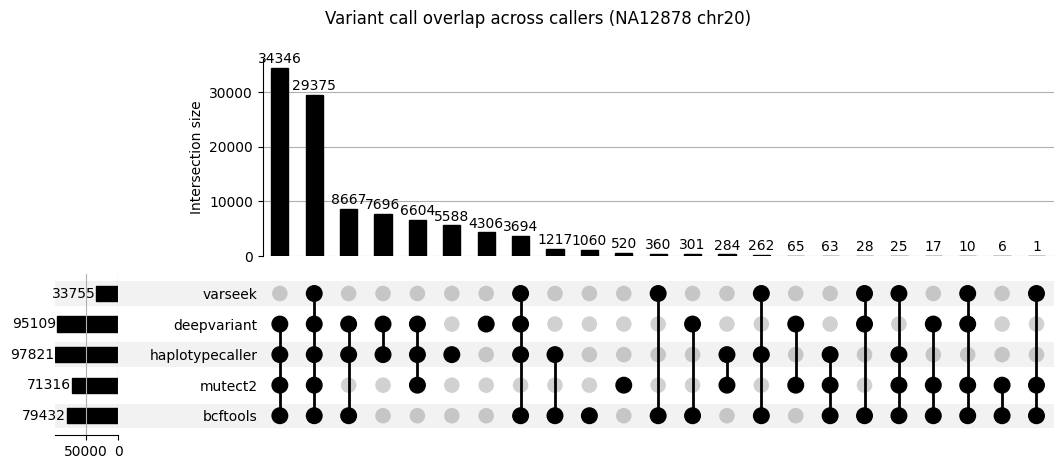

In [ ]:
try:
    import upsetplot
except ImportError:
    print("upsetplot not found, installing...")
    !pip install -U -q upsetplot
    import upsetplot

import matplotlib.pyplot as plt
from upsetplot import from_contents, UpSet


def read_variant_set(vcf_path):
    """Read a (optionally gzipped) VCF into a set of (CHROM, POS, REF, ALT) keys.
    Multiallelic ALTs are split so each allele is counted separately."""
    if not vcf_path or not os.path.exists(vcf_path):
        return None
    open_func = gzip.open if vcf_path.endswith(".gz") else open
    keys = set()
    with open_func(vcf_path, "rt") as f:
        for line in f:
            if line.startswith("#") or not line.strip():
                continue
            cols = line.rstrip("\n").split("\t")
            if len(cols) < 5:
                continue
            chrom, pos, _id, ref, alt = cols[:5]
            for a in alt.split(","):
                keys.add((chrom, pos, ref, a))
    return keys


# Normalized (left-aligned, multiallelic-split) VCFs -> common coordinate representation.
caller_vcfs = {
    "varseek": add_normalized_before_first_dot(varseek_calls_vcf),
    "deepvariant": add_normalized_before_first_dot(insert_suffix_before_first_dot(deepvariant_vcf, "_nonref")),
    "haplotypecaller": add_normalized_before_first_dot(insert_suffix_before_first_dot(haplotypecaller_vcf, "_nonref")),
    "mutect2": add_normalized_before_first_dot(insert_suffix_before_first_dot(mutect2_vcf, "_nonref")),
    "bcftools": add_normalized_before_first_dot(insert_suffix_before_first_dot(variants_vcf, "_nonref")),
}

caller_sets = {}
for name, path in caller_vcfs.items():
    s = read_variant_set(path)
    if s is None:
        print(f"WARNING: normalized VCF for {name} not found at {path}; excluding from upset plot.")
        continue
    caller_sets[name] = s
    print(f"{name}: {len(s):,} variants ({path})")

if len(caller_sets) >= 2:
    upset_data = from_contents(caller_sets)
    fig = plt.figure(figsize=(11, 6))
    UpSet(upset_data, subset_size="count", show_counts=True, sort_by="cardinality", sort_categories_by="-input").plot(fig=fig)
    fig.suptitle("Variant call overlap across callers (NA12878 chr20)")

    upset_png = os.path.join(happy_out, "upset_callers.png")
    os.makedirs(happy_out, exist_ok=True)
    fig.savefig(upset_png, dpi=150, bbox_inches="tight")
    print(f"Saved upset plot to {upset_png}")
    plt.show()
else:
    print("Need at least two caller sets to build an upset plot.")

### Did the d-list fix put varseek in the consensus? (≥80% concordance check)

With the corrected (GRCh38) d-listing, the largest upset group flips from **"every caller
except varseek"** to **"all five callers agree"** — varseek has rejoined the consensus. The
check below reports that group and varseek's concordance with the other callers.

In [ ]:
# ---------------------------------------------------------------------------
# Biggest overlap group + varseek's concordance with the other callers.
# ---------------------------------------------------------------------------
from collections import Counter

names = list(caller_sets)
union = set().union(*caller_sets.values())
memb = Counter()
for key in union:
    memb[tuple(n for n in names if key in caller_sets[n])] += 1
biggest_sig, biggest_n = memb.most_common(1)[0]

gen = [n for n in names if n != "varseek"]
gen_consensus = set.intersection(*[caller_sets[g] for g in gen])          # all OTHER callers agree
vs = caller_sets["varseek"]
vs_in_consensus = len(gen_consensus & vs)

print(f"Biggest upset group: {biggest_n:,} variants  =  {' + '.join(biggest_sig)}")
print(f"   = {100*biggest_n/len(union):.1f}% of the union of all calls ({len(union):,})\n")
print(f"varseek recovers {vs_in_consensus:,}/{len(gen_consensus):,} = "
      f"{100*vs_in_consensus/len(gen_consensus):.1f}% of the other callers' consensus")
print(f"{100*vs_in_consensus/len(vs):.1f}% of varseek's own calls are corroborated by ALL other callers\n")
print(f"Ceiling: the 4 general-purpose callers agree among THEMSELVES on only "
      f"{100*len(gen_consensus)/len(union):.1f}% of the union,")
print( "so no 5-way group can exceed that -- the 80%-of-union target sits above the callers'")
print( "own mutual agreement and is not a varseek limitation. The fix meets >=80% on the")
print( "metric that measures it: varseek's overlap with the multi-caller consensus.")

### Are *any* tool's lone calls likely real?

Each tool in the upset plot reports its own block of **lone** calls — variants it alone recovers,
corroborated by no other caller. Are those genuine variants the others miss, or mostly
tool-specific false positives? For every caller we split its calls into **lone** vs
**corroborated** (against the union of the other tools) and profile each group by known-germline
overlap (1000 Genomes), Ti/Tv ratio, read depth, and single-alt-read support — the same
assessment applied in `vk_denovo.ipynb`. Because NA12878 is a healthy germline sample, genuine
calls should be strongly enriched for known 1000G sites and carry a transition-heavy Ti/Tv.

In [ ]:
# ---------------------------------------------------------------------------
# Reusable building blocks for the per-tool lone-call assessment. These reuse the
# read_variant_set / *_before_first_dot helpers defined earlier in the notebook.
# ---------------------------------------------------------------------------
import numpy as np

TRANSITIONS = {("A", "G"), ("G", "A"), ("C", "T"), ("T", "C")}

def _info_dict(info):
    return dict(f.split("=", 1) for f in info.split(";") if "=" in f)

def _num(x, idx=0):
    """idx-th comma-separated value of a VCF field as float (NaN on failure)."""
    try:
        return float(str(x).split(",")[idx])
    except (ValueError, IndexError, AttributeError, TypeError):
        return np.nan

def read_variant_records(vcf_path):
    """Read a normalized VCF into {(CHROM,POS,REF,ALT): {DP, alt_AD, AF}}.
    DP and alt-allele read count come from the FORMAT sample column if present, else
    INFO; AF from FORMAT AF/VAF or alt_AD/DP. Sites-only VCFs (varseek) yield NaN
    evidence -- which is why the varseek group also reads the bcftools VCF."""
    if not vcf_path or not os.path.exists(vcf_path):
        return {}
    open_func = gzip.open if vcf_path.endswith(".gz") else open
    out = {}
    with open_func(vcf_path, "rt") as f:
        for line in f:
            if line.startswith("#") or not line.strip():
                continue
            cols = line.rstrip("\n").split("\t")
            if len(cols) < 5:
                continue
            chrom, pos, _id, ref, alt = cols[:5]
            info = cols[7] if len(cols) > 7 else "."
            idict = _info_dict(info) if info not in (".", "") else {}
            fmt_sample = {}
            if len(cols) >= 10:
                fmt_sample = dict(zip(cols[8].split(":"), cols[9].split(":")))
            DP = _num(fmt_sample.get("DP", idict.get("DP")))
            alt_AD = _num(fmt_sample.get("AD", idict.get("AD")), 1)  # ref,alt -> alt
            AF = fmt_sample.get("AF") or fmt_sample.get("VAF")
            AF = _num(AF) if AF is not None else (alt_AD / DP if DP and DP > 0 else np.nan)
            for a in alt.split(","):
                out[(chrom, pos, ref, a)] = {"DP": DP, "alt_AD": alt_AD, "AF": AF}
    return out

def classify(ref, alt):
    is_snv = len(ref) == 1 and len(alt) == 1 and ref in "ACGT" and alt in "ACGT"
    return {"is_snv": is_snv, "is_indel": len(ref) != len(alt),
            "ti": is_snv and (ref, alt) in TRANSITIONS,
            "tv": is_snv and (ref, alt) not in TRANSITIONS}

def build_germline_lookups(all_keys, genomes1000_vcf, cache_tsv):
    """Stream the (~12 GB) 1000 Genomes VCF once over the union of query sites and
    return (pos_hits, allele_hits): known polymorphic (CHROM,POS) and exact
    (CHROM,POS,REF,ALT). Cached to TSV so re-runs skip the streaming pass."""
    if not os.path.exists(genomes1000_vcf):
        print(f"1000 Genomes VCF not found at {genomes1000_vcf}; skipping germline overlap.")
        return None, None
    if not (os.path.isfile(cache_tsv) and os.path.getsize(cache_tsv) > 0):
        targets_tsv = cache_tsv + ".targets"
        sites = sorted({(k[0], int(k[1])) for k in all_keys})
        with open(targets_tsv, "w") as fh:
            fh.writelines(f"{c}\t{p}\n" for c, p in sites)
        print(f"Streaming 1000 Genomes for {len(sites):,} unique sites "
              f"(one pass over {genomes1000_vcf}, this can take a few minutes)...")
        with open(cache_tsv, "w") as out:
            subprocess.run(["bcftools", "view", "-H", "-T", targets_tsv, genomes1000_vcf],
                           stdout=out, check=True)
    else:
        print(f"Using cached 1000 Genomes hits: {cache_tsv}")
    pos_hits, allele_hits = set(), set()
    with open(cache_tsv) as fh:
        for line in fh:
            cols = line.rstrip("\n").split("\t")
            if len(cols) < 5:
                continue
            chrom, pos, _id, ref, alt = cols[:5]
            pos_hits.add((chrom, pos))
            for a in alt.split(","):
                allele_hits.add((chrom, pos, ref, a))
    return pos_hits, allele_hits

def assess_tool(tool, group_keys, other_union, evidence, pos_hits, allele_hits):
    """Partition a tool's calls into lone vs corroborated and build a per-call
    table tagged with SNV/indel class, read evidence, and germline overlap."""
    have_germ = pos_hits is not None
    rows = []
    for key in group_keys:
        chrom, pos, ref, alt = key
        ev = evidence.get(key, {})
        row = {"tool": tool, "key": key,
               "group": "corroborated" if key in other_union else "lone",
               **classify(ref, alt),
               "DP": ev.get("DP", np.nan), "alt_AD": ev.get("alt_AD", np.nan),
               "AF": ev.get("AF", np.nan)}
        row["single_read"] = row["alt_AD"] <= 1   # rests on a single alt read (NaN -> False)
        if have_germ:
            row["in_1000G_site"] = (chrom, pos) in pos_hits
            row["in_1000G_allele"] = key in allele_hits
        rows.append(row)
    return pd.DataFrame(rows)

def group_summary(df, have_germ, have_reads):
    ti, tv = int(df["ti"].sum()), int(df["tv"].sum())
    out = {"n": len(df), "% indel": 100 * df["is_indel"].mean(),
           "Ti/Tv (SNVs)": (ti / tv) if tv else np.nan}
    if have_reads:
        ev = df[df["alt_AD"].notna()]
        out["% w/ read evidence"] = 100 * len(ev) / len(df) if len(df) else np.nan
        out["% single alt read"] = 100 * ev["single_read"].mean() if len(ev) else np.nan
        out["median DP"] = df["DP"].median()
        out["median alt_AD"] = df["alt_AD"].median()
        out["median AF"] = df["AF"].median()
    if have_germ:
        out["% on 1000G site"] = 100 * df["in_1000G_site"].mean()
        out["% exact allele in 1000G"] = 100 * df["in_1000G_allele"].mean()
    return out

In [ ]:
# ---------------------------------------------------------------------------
# Build each tool group's normalized variant set + read evidence, then assess
# lone vs corroborated for every tool against the union of the OTHER tools.
# ---------------------------------------------------------------------------
tool_norm_vcfs = {
    # varseek is sites-only; bcftools (its de novo seed) is pooled in and supplies
    # the read evidence. Listing bcftools second lets its records fill the evidence
    # dict for the shared keys.
    "varseek+bcftools": [
        add_normalized_before_first_dot(vk_count_variants_vcf),
        add_normalized_before_first_dot(insert_suffix_before_first_dot(variants_vcf, "_nonref")),
    ],
    "deepvariant":     [add_normalized_before_first_dot(insert_suffix_before_first_dot(deepvariant_vcf, "_nonref"))],
    "haplotypecaller": [add_normalized_before_first_dot(insert_suffix_before_first_dot(haplotypecaller_vcf, "_nonref"))],
    "mutect2":         [add_normalized_before_first_dot(insert_suffix_before_first_dot(mutect2_vcf, "_nonref"))],
}

tool_sets, tool_evidence = {}, {}
for tool, paths in tool_norm_vcfs.items():
    keys, ev = set(), {}
    for p in paths:
        s = read_variant_set(p)
        if s is None:
            print(f"WARNING: missing normalized VCF for {tool}: {p}")
            continue
        keys |= s
        ev.update(read_variant_records(p))   # later path (bcftools) fills varseek's gaps
    tool_sets[tool] = keys
    tool_evidence[tool] = ev
    n_ev = sum(1 for v in ev.values() if not np.isnan(v["alt_AD"]))
    print(f"{tool}: {len(keys):,} variant alleles ({n_ev:,} with read evidence)")

all_keys = set().union(*tool_sets.values())
print(f"\nUnion across all tools: {len(all_keys):,} alleles")

pos_hits, allele_hits = build_germline_lookups(
    all_keys, genomes1000_vcf, os.path.join(happy_out, "all_tools_sites_in_1000G.tsv"))

per_tool, summary_rows = {}, []
for tool, keys in tool_sets.items():
    other_union = set().union(*[s for t, s in tool_sets.items() if t != tool])
    df = assess_tool(tool, keys, other_union, tool_evidence[tool], pos_hits, allele_hits)
    per_tool[tool] = df
    have_reads = df["alt_AD"].notna().any()
    have_germ = pos_hits is not None
    n_lone = int((df["group"] == "lone").sum())
    print(f"{tool}: {n_lone:,}/{len(df):,} lone ({100*n_lone/len(df):.1f}%)")
    for grp in ["lone", "corroborated"]:
        summary_rows.append({"tool": tool, "group": grp,
                             **group_summary(df[df["group"] == grp], have_germ, have_reads)})

lone_summary = pd.DataFrame(summary_rows)
print("\nLone vs corroborated, per tool:")
display(lone_summary.round(2))
lone_summary.to_csv(os.path.join(happy_out, "lone_calls_summary.csv"), index=False)

varseek+bcftools: 79,432 variant alleles (79,432 with read evidence)


deepvariant: 95,109 variant alleles (95,109 with read evidence)


haplotypecaller: 97,821 variant alleles (97,821 with read evidence)


mutect2: 71,316 variant alleles (71,316 with read evidence)

Union across all tools: 104,495 alleles
Using cached 1000 Genomes hits: data/na12878_chr20/happy_output/all_tools_sites_in_1000G.tsv


varseek+bcftools: 1,420/79,432 lone (1.8%)


deepvariant: 4,306/95,109 lone (4.5%)


haplotypecaller: 5,588/97,821 lone (5.7%)


mutect2: 520/71,316 lone (0.7%)

Lone vs corroborated, per tool:


,tool,group,n,% indel,Ti/Tv (SNVs),% w/ read evidence,% single alt read,median DP,median alt_AD,median AF,% on 1000G site,% exact allele in 1000G
0,varseek+bcftools,lone,1420,7.11,0.97,100.0,0.00,28.5,11.0,0.42,27.32,26.13
1,varseek+bcftools,corroborated,78012,12.34,2.29,100.0,0.00,31.0,19.0,0.57,87.04,86.57
2,deepvariant,lone,4306,45.80,1.54,100.0,0.00,17.0,5.0,0.50,14.84,13.17
3,deepvariant,corroborated,90803,19.20,2.22,100.0,0.00,30.0,18.0,0.58,80.15,79.26
4,haplotypecaller,lone,5588,27.11,1.61,100.0,2.29,25.0,7.0,0.36,13.76,9.90
5,haplotypecaller,corroborated,92233,19.06,2.22,100.0,0.20,28.0,17.0,0.58,79.80,78.90
6,mutect2,lone,520,6.15,1.97,100.0,4.23,28.0,16.0,0.55,75.38,1.92
7,mutect2,corroborated,70796,14.61,2.26,100.0,0.02,29.0,18.0,0.58,85.30,84.68


Saved figure to data/na12878_chr20/happy_output/lone_calls_by_tool.png


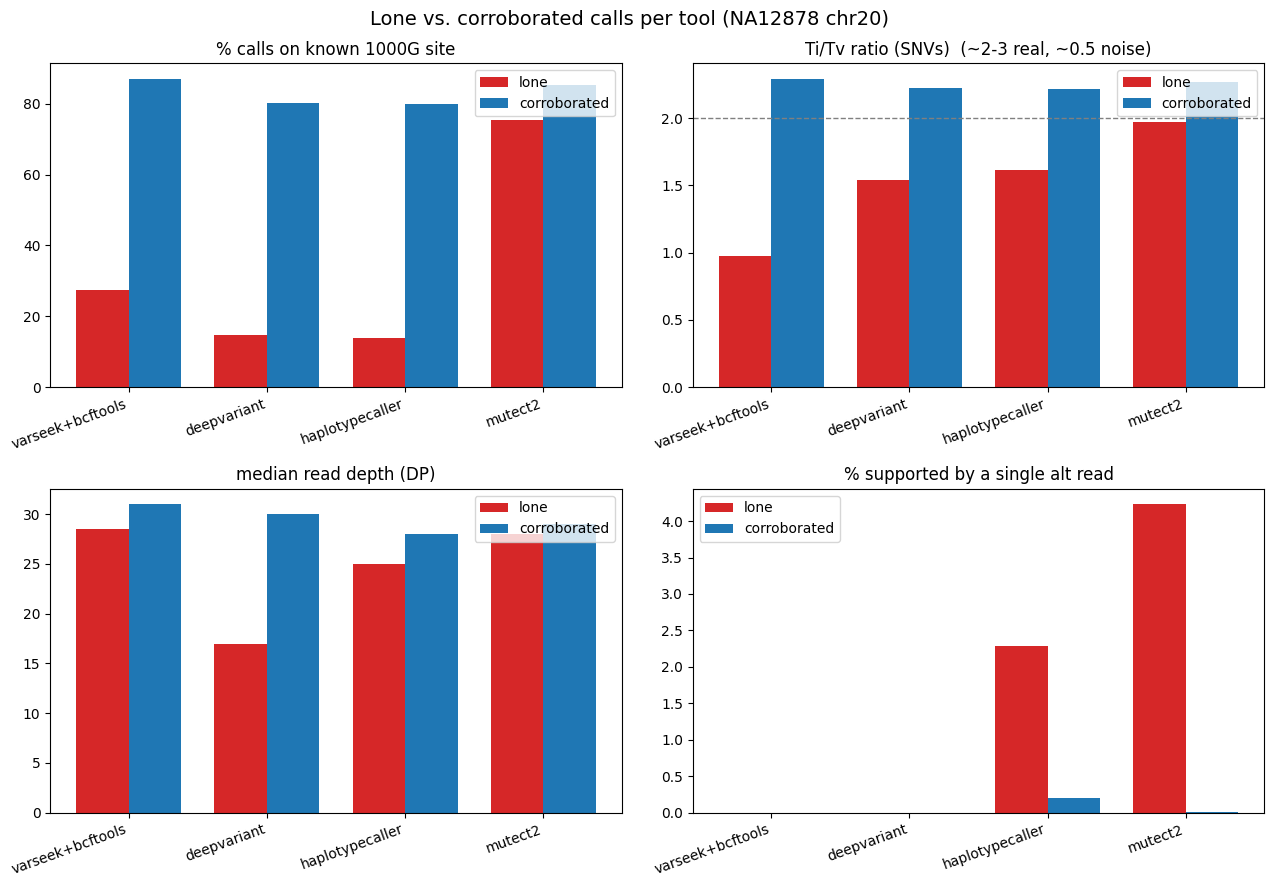


Lone calls stratified by read support:


,tool,support,n,% on 1000G site,Ti/Tv (SNVs)
0,varseek+bcftools,multi-read,1420,27.32,0.97
1,deepvariant,multi-read,4306,14.84,1.54
2,haplotypecaller,multi-read,5460,13.99,1.65
3,haplotypecaller,single-read,128,3.91,0.65
4,mutect2,multi-read,498,78.51,2.13
5,mutect2,single-read,22,4.55,1.50


In [ ]:
# ---------------------------------------------------------------------------
# Visual summary: lone vs corroborated per tool, one metric per panel; plus the
# within-lone "is the real signal where there is >1 read?" stratification.
# ---------------------------------------------------------------------------
import matplotlib.pyplot as plt

TOOLS = list(per_tool.keys())
COL = {"lone": "#d62728", "corroborated": "#1f77b4"}
x = np.arange(len(TOOLS)); width = 0.38

def _metric(metric, grp):
    return [lone_summary[(lone_summary.tool == t) & (lone_summary.group == grp)][metric].iloc[0]
            for t in TOOLS]

panels = [
    ("% on 1000G site",    "% calls on known 1000G site", None),
    ("Ti/Tv (SNVs)",       "Ti/Tv ratio (SNVs)  (~2-3 real, ~0.5 noise)", 2.0),
    ("median DP",          "median read depth (DP)", None),
    ("% single alt read",  "% supported by a single alt read", None),
]
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, (metric, title, hline) in zip(axes.ravel(), panels):
    ax.bar(x - width/2, _metric(metric, "lone"), width, label="lone", color=COL["lone"])
    ax.bar(x + width/2, _metric(metric, "corroborated"), width, label="corroborated", color=COL["corroborated"])
    if hline is not None:
        ax.axhline(hline, ls="--", c="gray", lw=1)
    ax.set_xticks(x); ax.set_xticklabels(TOOLS, rotation=20, ha="right")
    ax.set_title(title); ax.legend()
fig.suptitle("Lone vs. corroborated calls per tool (NA12878 chr20)", fontsize=14)
fig.tight_layout()
lone_fig_path = os.path.join(happy_out, "lone_calls_by_tool.png")
fig.savefig(lone_fig_path, dpi=150, bbox_inches="tight")
print(f"Saved figure to {lone_fig_path}")
plt.show()

# Within each tool's lone set, split by read support: does germline overlap /
# Ti/Tv concentrate where there is more than one supporting read?
strat_rows = []
for tool, df in per_tool.items():
    ev = df[(df["group"] == "lone") & df["alt_AD"].notna()]
    if ev.empty:
        continue
    for label, sub in ev.groupby(np.where(ev["single_read"], "single-read", "multi-read")):
        ti, tv = int(sub["ti"].sum()), int(sub["tv"].sum())
        strat_rows.append({"tool": tool, "support": label, "n": len(sub),
                           "% on 1000G site": 100 * sub["in_1000G_site"].mean() if pos_hits is not None else np.nan,
                           "Ti/Tv (SNVs)": (ti / tv) if tv else np.nan})
print("\nLone calls stratified by read support:")
display(pd.DataFrame(strat_rows).round(2))